In [26]:
import pandas as pd

df_empresas = pd.read_csv(r"../data/clean/empresas_transporte_final_limpio.csv")
df_migracion = pd.read_csv(r"../data/clean/migracion_municipios_final_limpio.csv")
df_rentamedia = pd.read_csv(r"../data/clean/rentamedia_municipios_final_limpio.csv")
df_viirs = pd.read_csv(r"../data/clean/viirsFinal_limpio.csv")

In [17]:
for df in [df_empresas, df_migracion, df_rentamedia, df_viirs]:
    print(df.info())
    print(df.head())
    print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8188 entries, 0 to 8187
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   codigo  8188 non-null   int64  
 1   nombre  8188 non-null   object 
 2   tipo    8188 non-null   object 
 3   2012    8188 non-null   float64
 4   2013    8188 non-null   float64
 5   2014    8188 non-null   float64
 6   2015    8188 non-null   float64
 7   2016    8188 non-null   float64
 8   2017    8188 non-null   float64
 9   2018    8188 non-null   float64
 10  2019    8188 non-null   float64
 11  2020    8188 non-null   float64
 12  2021    8188 non-null   float64
 13  2022    8188 non-null   float64
 14  2023    8188 non-null   float64
 15  2024    8188 non-null   float64
 16  2025    8188 non-null   float64
dtypes: float64(14), int64(1), object(2)
memory usage: 1.1+ MB
None
   codigo            nombre       tipo   2012   2013   2014   2015   2016  \
0    1001  Alegría-Dulantzi  municipio   55.0

## Transporte empresas

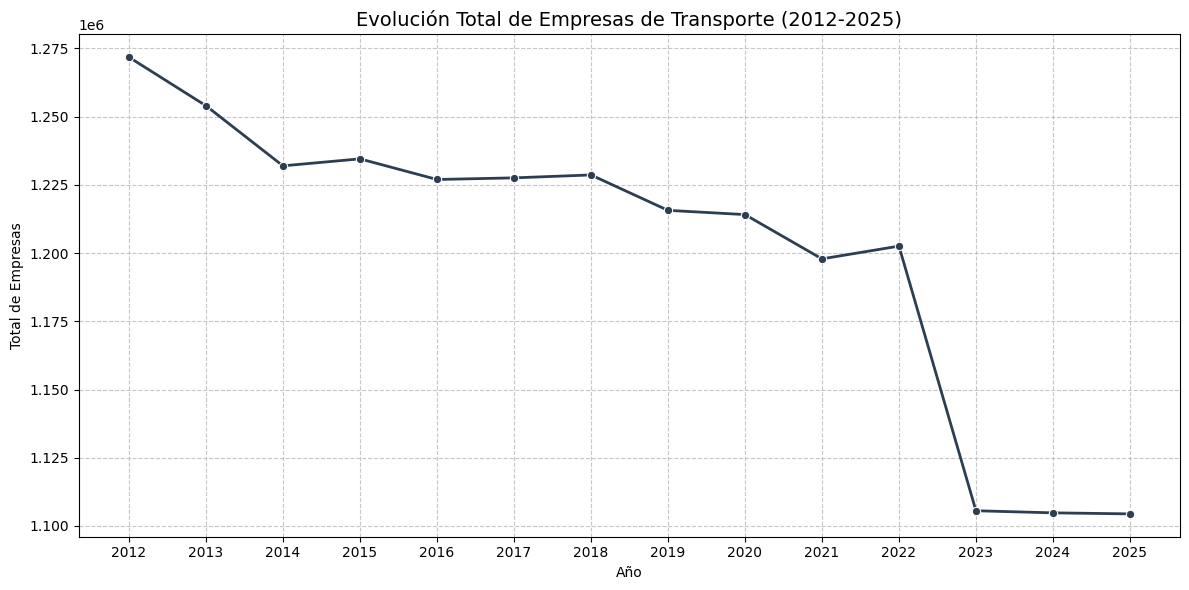

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_22848\1341599765.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




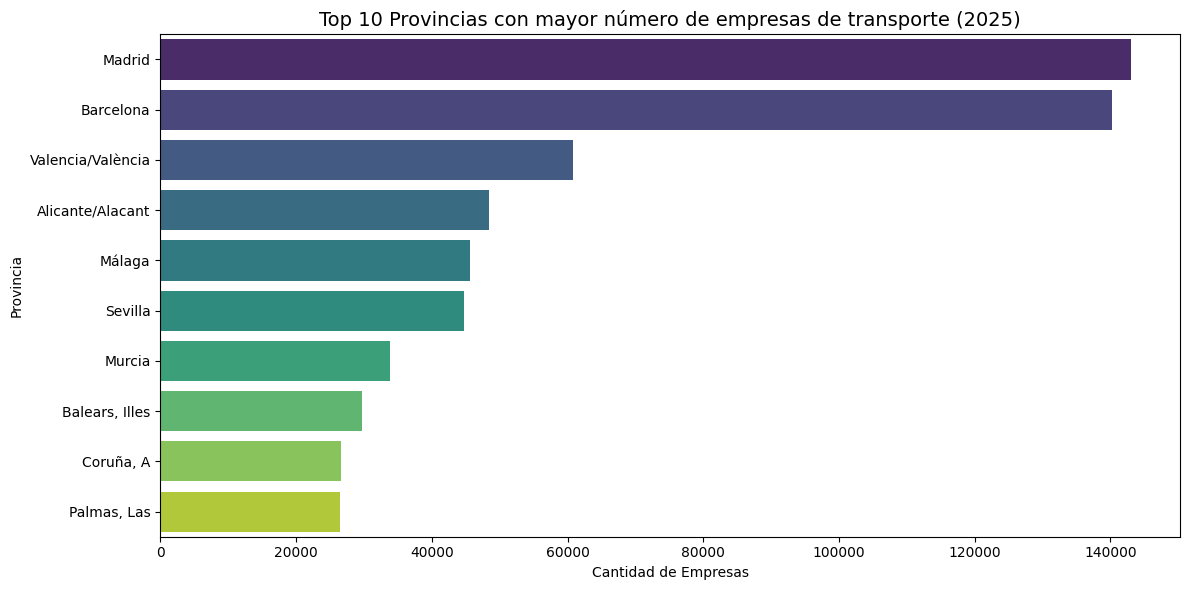

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
# 2. Transformación de Wide a Long (Melt)
# Conservamos 'codigo', 'nombre' y 'tipo', y convertimos los años en filas
df_empresas_long = df_empresas.melt(
    id_vars=['codigo', 'nombre', 'tipo'], 
    var_name='anio', 
    value_name='cantidad_empresas'
)

# Convertir la columna 'anio' a tipo numérico para poder graficar correctamente
df_empresas_long['anio'] = pd.to_numeric(df_empresas_long['anio'])

# 3. Separar las granularidades para el análisis
df_municipios = df_empresas_long[df_empresas_long['tipo'] == 'municipio']
df_provincias = df_empresas_long[df_empresas_long['tipo'] == 'provincia']

# ==========================================
# GRÁFICA 1: Evolución total de empresas en España (2012-2025)
# ==========================================
plt.figure(figsize=(12, 6))
# Agrupamos por año sumando las empresas de todas las provincias
evolucion_total = df_provincias.groupby('anio')['cantidad_empresas'].sum().reset_index()

sns.lineplot(data=evolucion_total, x='anio', y='cantidad_empresas', marker='o', linewidth=2, color='#2c3e50')
plt.title('Evolución Total de Empresas de Transporte (2012-2025)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Total de Empresas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(evolucion_total['anio']) # Mostrar todos los años en el eje X
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICA 2: Top 10 Provincias con más empresas en el último año (2025)
# ==========================================
plt.figure(figsize=(12, 6))
empresas_2025 = df_provincias[df_provincias['anio'] == 2025].sort_values(by='cantidad_empresas', ascending=False).head(10)

sns.barplot(data=empresas_2025, x='cantidad_empresas', y='nombre', palette='viridis')
plt.title('Top 10 Provincias con mayor número de empresas de transporte (2025)', fontsize=14)
plt.xlabel('Cantidad de Empresas')
plt.ylabel('Provincia')
plt.tight_layout()
plt.show()

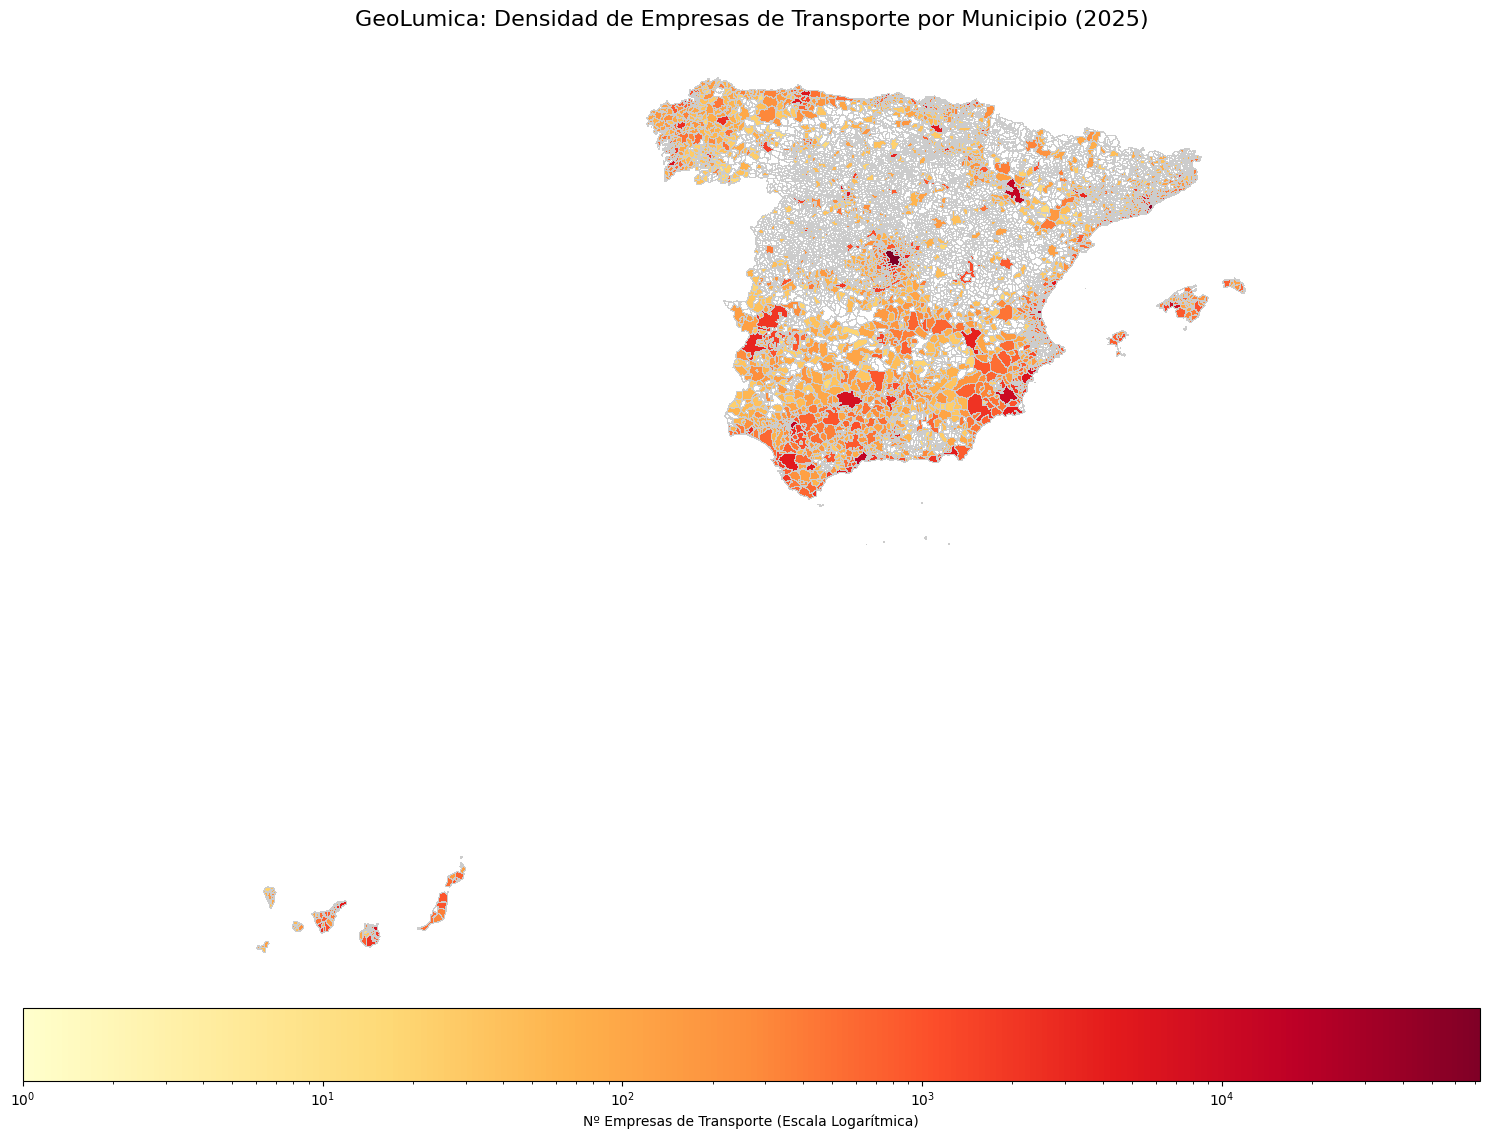

In [23]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Rutas (ajustadas a tu estructura)
path_csv = r"../data/clean/empresas_transporte_final_limpio.csv"
path_geojson = r"../municipios_es.geojson"

# 2. Carga de datos
df_wide = pd.read_csv(path_csv)
geo_muni = gpd.read_file(path_geojson)

# 3. Preparar datos de empresas (Filtro municipios y año 2025)
df_2025 = df_wide[df_wide['tipo'] == 'municipio'][['codigo', '2025']].copy()
df_2025['codigo_id'] = df_2025['codigo'].astype(str).str.zfill(5)

# 4. Cruce de datos (Usando LAU_ID del GeoJSON)
merged = geo_muni.merge(df_2025, left_on='LAU_ID', right_on='codigo_id', how='left')
merged['2025'] = merged['2025'].fillna(0)

# 5. Generación del Mapa con Escala Logarítmica
# (Evitamos el error 'scheme' usando LogNorm)
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
ax.set_facecolor('#f0f0f0')

# Usamos LogNorm para que los municipios con pocas empresas sean visibles
# Sumamos 0.1 para evitar log(0)
vmin = merged['2025'].min() + 0.1
vmax = merged['2025'].max()

merged.plot(
    column='2025',
    cmap='YlOrRd',
    norm=LogNorm(vmin=1, vmax=vmax), # Escala logarítmica manual
    antialiased=False,
    legend=True,
    ax=ax,
    edgecolor='0.8',
    linewidth=0.05,
    legend_kwds={'label': "Nº Empresas de Transporte (Escala Logarítmica)", 'orientation': "horizontal", 'pad': 0.01}
)

plt.title("GeoLumica: Densidad de Empresas de Transporte por Municipio (2025)", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Migracion

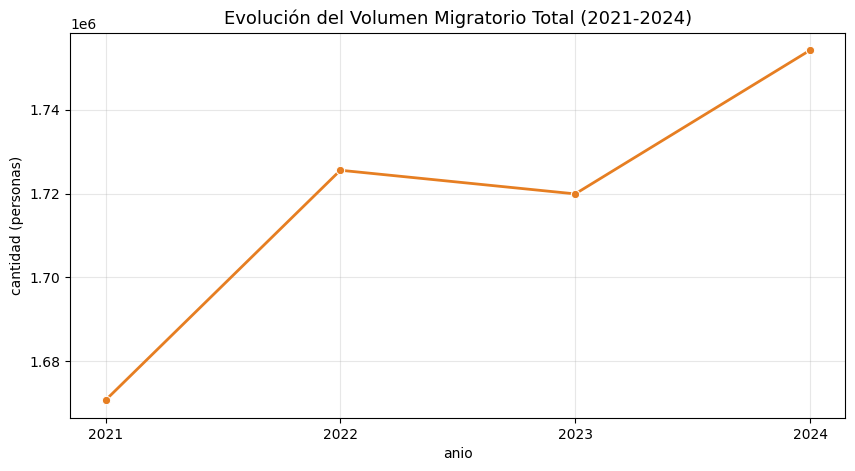

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_22848\2357329924.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




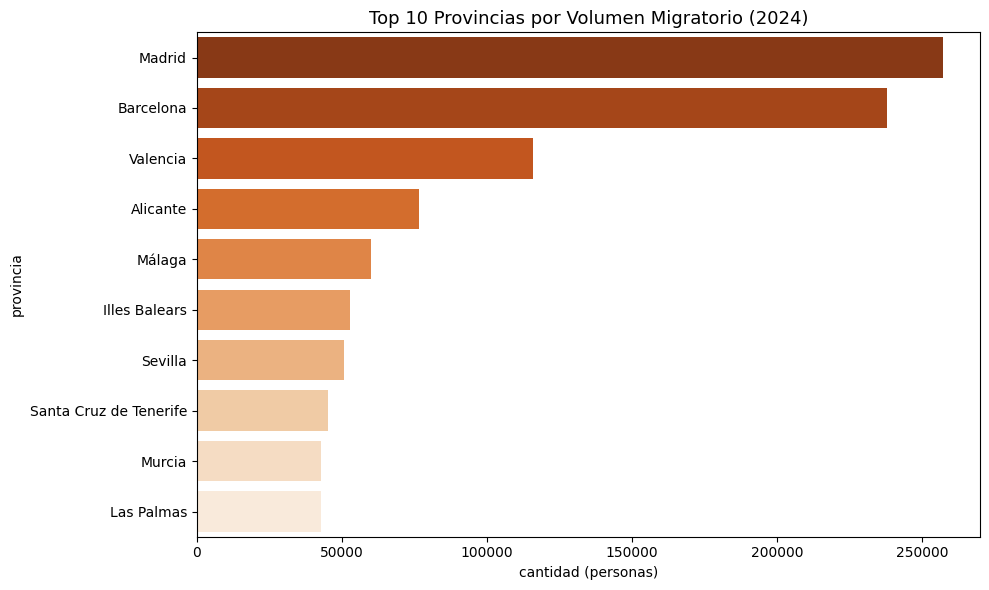

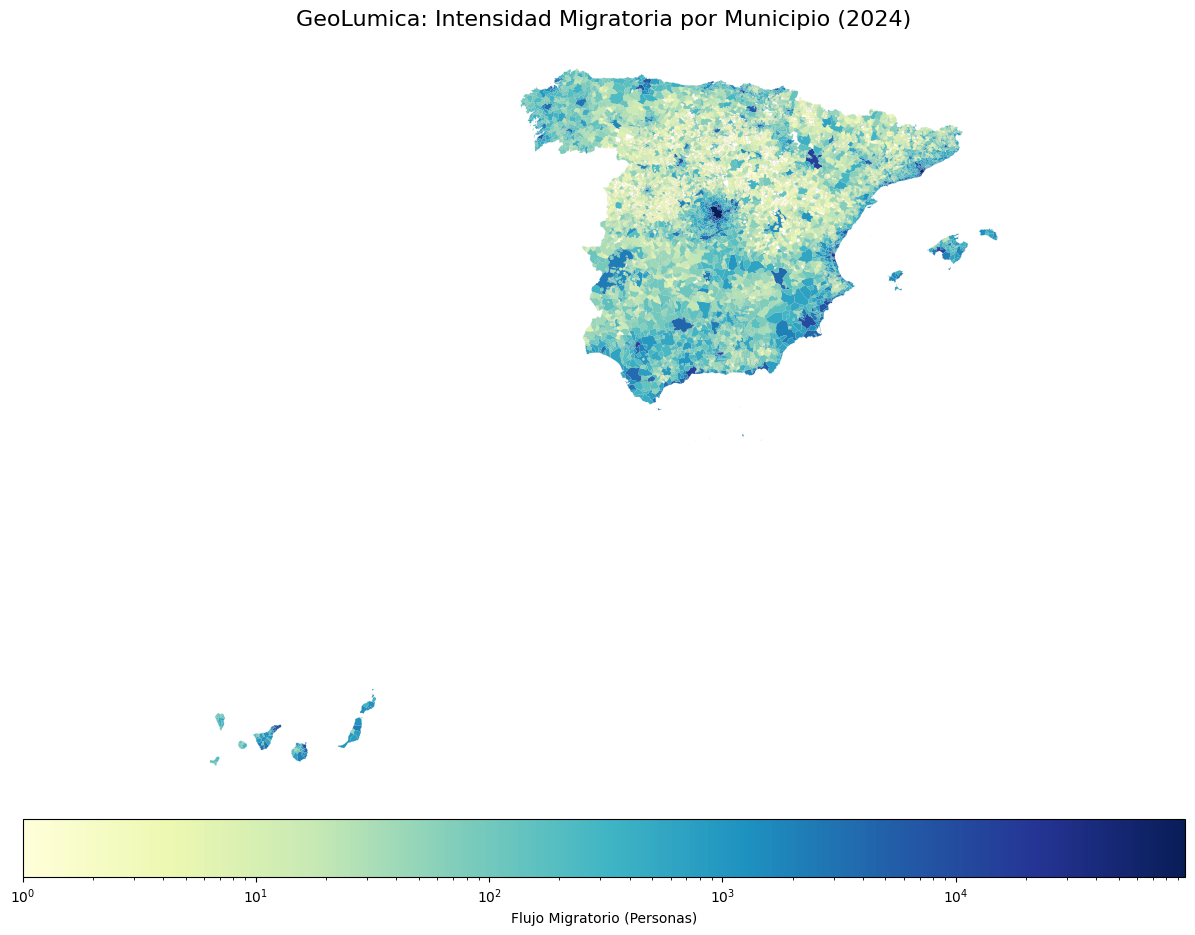

In [35]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# 1. Preparación de datos (df_migracion ya está cargado)
# Se asegura que el código de municipio sea un string de 5 dígitos para el GeoJSON
df_migracion['codigo_id'] = df_migracion['codigo_municipio'].astype(str).str.zfill(5)

# 2. GRÁFICA 1: Evolución del Volumen Migratorio Total
plt.figure(figsize=(10, 5))
mig_anual = df_migracion[df_migracion['nacionalidad'] == 'Total'].groupby('anio')['cantidad (personas)'].sum().reset_index()
sns.lineplot(data=mig_anual, x='anio', y='cantidad (personas)', marker='o', color='#e67e22', linewidth=2)
plt.title('Evolución del Volumen Migratorio Total (2021-2024)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.xticks(mig_anual['anio'])
plt.show()

# 3. GRÁFICA 2: Top 10 Provincias con mayor flujo (2024)
plt.figure(figsize=(10, 6))
top_prov_2024 = df_migracion[(df_migracion['anio'] == 2024) & (df_migracion['nacionalidad'] == 'Total')] \
                .groupby('provincia')['cantidad (personas)'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=top_prov_2024, x='cantidad (personas)', y='provincia', palette='Oranges_r')
plt.title('Top 10 Provincias por Volumen Migratorio (2024)', fontsize=13)
plt.tight_layout()
plt.show()

# 4. MAPA MUNICIPAL: Intensidad Migratoria (2024)
# Cargamos el GeoJSON desde la raíz
geo_muni = gpd.read_file(r"../municipios_es.geojson")

# Filtramos datos para el mapa
df_mapa = df_migracion[(df_migracion['anio'] == 2024) & (df_migracion['nacionalidad'] == 'Total')]
merged_mig = geo_muni.merge(df_mapa, left_on='LAU_ID', right_on='codigo_id', how='left')
merged_mig['cantidad (personas)'] = merged_mig['cantidad (personas)'].fillna(0)

# Generación del mapa sin usar 'scheme' para evitar errores de librerías
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
ax.set_facecolor('#fdfefe')

# Usamos LogNorm para que los municipios pequeños tengan color y Madrid/Barcelona no eclipsen todo
vmax = merged_mig['cantidad (personas)'].max()
merged_mig.plot(
    column='cantidad (personas)',
    cmap='YlGnBu', # Escala de azul/verde para diferenciarlo del mapa de empresas
    norm=LogNorm(vmin=1, vmax=vmax),
    legend=True,
    ax=ax,
    linewidth=0.05,
    edgecolor='0.7',
    legend_kwds={'label': "Flujo Migratorio (Personas)", 'orientation': "horizontal", 'pad': 0.02}
)

plt.title("GeoLumica: Intensidad Migratoria por Municipio (2024)", fontsize=16)
ax.set_axis_off()
plt.show()



## Renta Media (PIB)

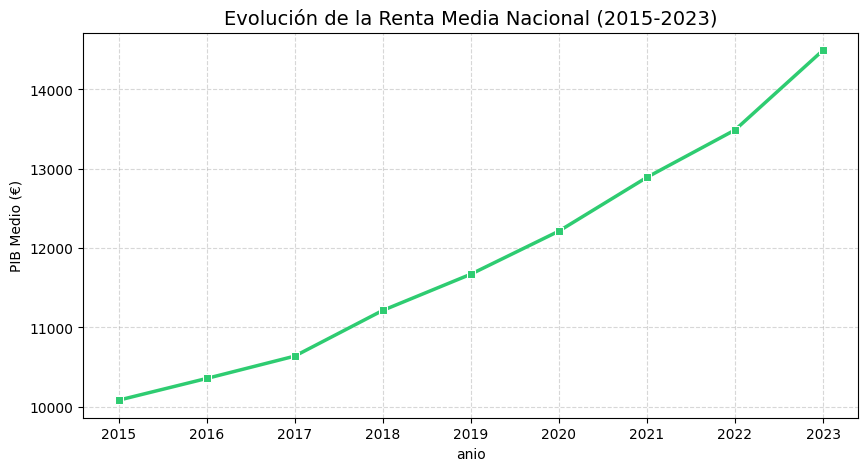

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_22848\393079334.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




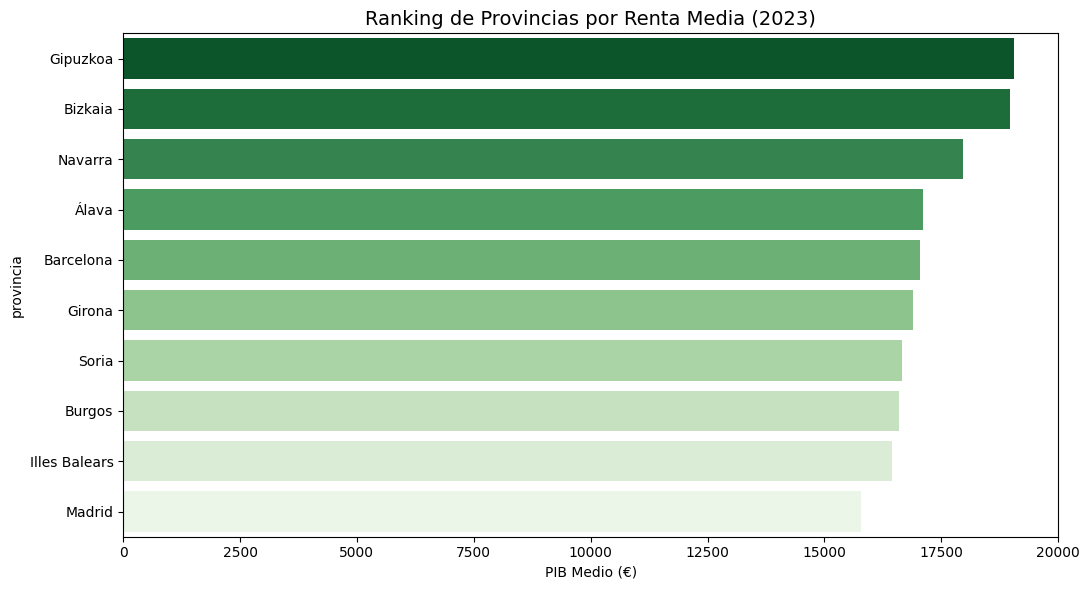

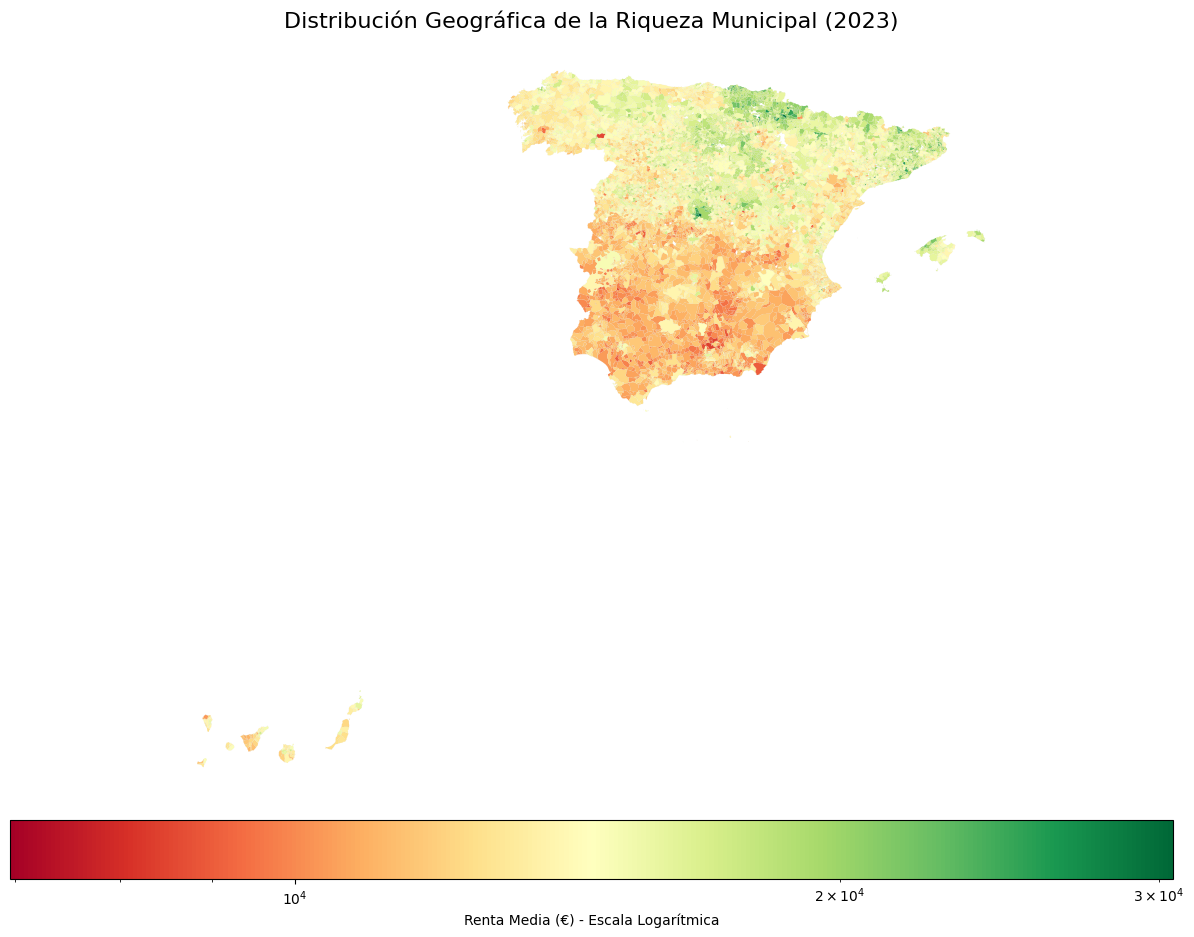

In [37]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# 1. Preparación de datos (df_renta_media ya está cargado)
# Normalizamos el código de municipio a 5 dígitos
df_rentamedia['codigo_id'] = df_rentamedia['codigo_municipio'].astype(str).str.zfill(5)

# ---------------------------------------------------------
# GRÁFICA 1: Evolución del PIB Medio Nacional (2015-2023)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
pib_anual = df_rentamedia.groupby('anio')['pib'].mean().reset_index()
sns.lineplot(data=pib_anual, x='anio', y='pib', marker='s', color='#2ecc71', linewidth=2.5)
plt.title('Evolución de la Renta Media Nacional (2015-2023)', fontsize=14)
plt.ylabel('PIB Medio (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ---------------------------------------------------------
# GRÁFICA 2: Top 10 Provincias con Mayor PIB (Último año)
# ---------------------------------------------------------
plt.figure(figsize=(11, 6))
ultimo_anio = df_rentamedia['anio'].max()
top_10_pib = df_rentamedia[df_rentamedia['anio'] == ultimo_anio] \
             .groupby('provincia')['pib'].mean().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_10_pib, x='pib', y='provincia', palette='Greens_r')
plt.title(f'Ranking de Provincias por Renta Media ({ultimo_anio})', fontsize=14)
plt.xlabel('PIB Medio (€)')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRÁFICA 3: Mapa de Riqueza Municipal
# ---------------------------------------------------------
# Cargamos el GeoJSON
geo_muni = gpd.read_file(r"../municipios_es.geojson")

# Filtramos datos para el mapa (año más reciente)
df_mapa_pib = df_rentamedia[df_rentamedia['anio'] == ultimo_anio]
merged_pib = geo_muni.merge(df_mapa_pib, left_on='LAU_ID', right_on='codigo_id', how='left')
merged_pib['pib'] = merged_pib['pib'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(15, 12))
ax.set_facecolor('#f8f9f9')

# Usamos LogNorm para ver la gradación de riqueza sin que Madrid/País Vasco lo tapen todo
vmax = merged_pib['pib'].max()
merged_pib.plot(
    column='pib',
    cmap='RdYlGn', # De rojo (pobreza) a verde (riqueza)
    norm=LogNorm(vmin=merged_pib[merged_pib['pib']>0]['pib'].min(), vmax=vmax),
    legend=True,
    ax=ax,
    linewidth=0.03,
    edgecolor='0.8',
    legend_kwds={'label': "Renta Media (€) - Escala Logarítmica", 'orientation': "horizontal", 'pad': 0.02}
)

plt.title(f"Distribución Geográfica de la Riqueza Municipal ({ultimo_anio})", fontsize=16)
ax.set_axis_off()
plt.show()

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_22848\1369935107.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




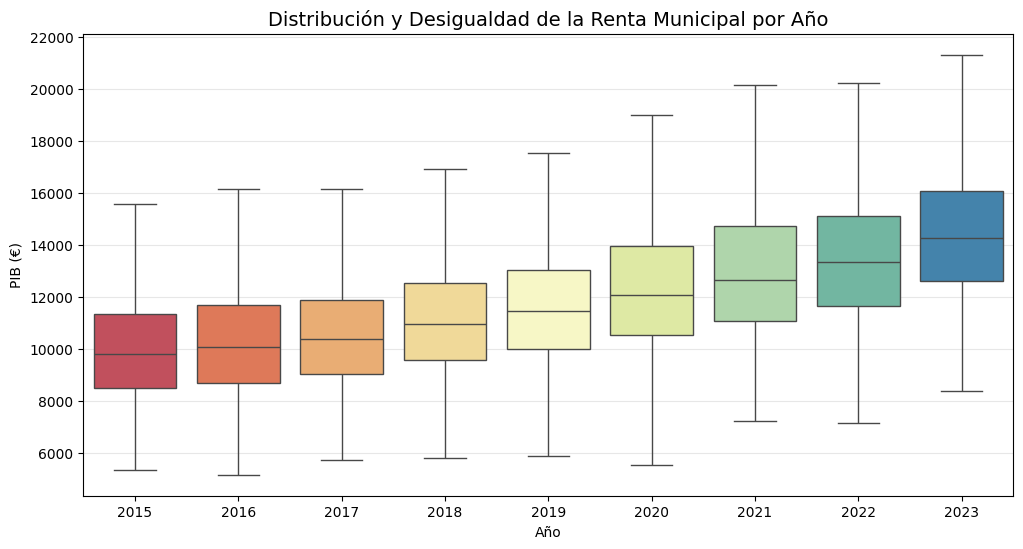

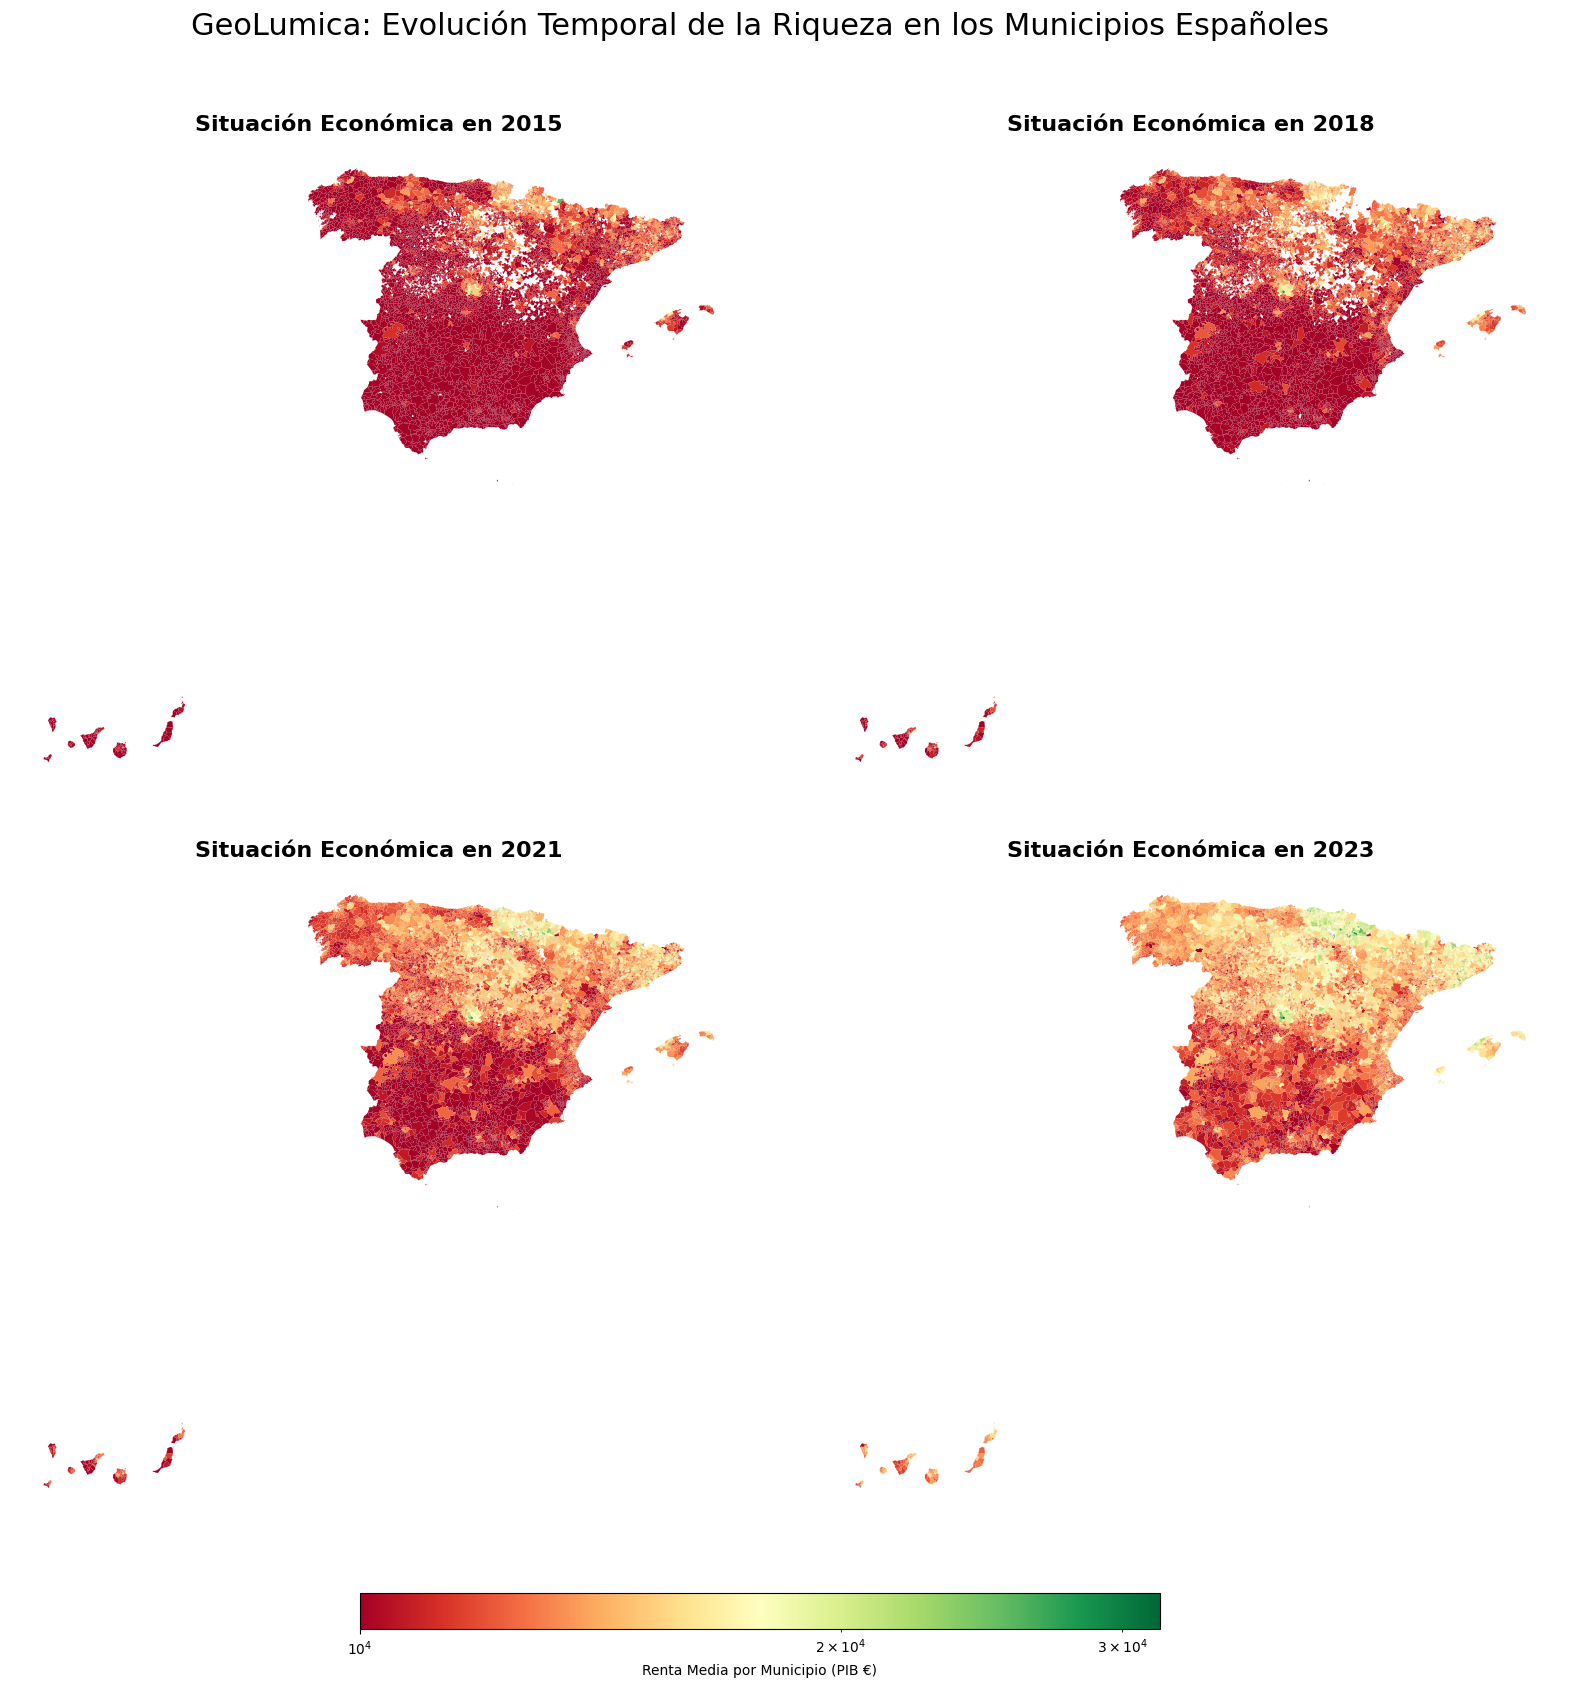

In [40]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# 1. Boxplot: ¿Se está volviendo España más desigual?
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_rentamedia, x='anio', y='pib', palette='Spectral', showfliers=False)
plt.title('Distribución y Desigualdad de la Renta Municipal por Año', fontsize=14)
plt.ylabel('PIB (€)')
plt.xlabel('Año')
plt.grid(axis='y', alpha=0.3)
plt.show()

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# 1. Preparación previa
df_rentamedia['codigo_id'] = df_rentamedia['codigo_municipio'].astype(str).str.zfill(5)
geo_muni = gpd.read_file(r"../municipios_es.geojson")

# 2. Selección de años para los subplots (Ej: Inicio, Mitad, Actualidad)
# Puedes ajustar esta lista según prefieras
años_mapas = [2015, 2018, 2021, 2023] 

# Configuramos la cuadrícula (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
ax_list = axes.flatten()

# Definimos una escala común para que la comparación sea visualmente honesta
# Usamos un vmin razonable para no saturar los municipios con 0
vmax = df_rentamedia['pib'].max()
vmin = 10000 

for i, anio in enumerate(años_mapas):
    # Filtrar datos del año y unir con el mapa
    df_temp = df_rentamedia[df_rentamedia['anio'] == anio]
    merged_temp = geo_muni.merge(df_temp, left_on='LAU_ID', right_on='codigo_id', how='left')
    
    # Dibujar el mapa en el subplot correspondiente
    merged_temp.plot(
        column='pib',
        ax=ax_list[i],
        cmap='RdYlGn',
        norm=LogNorm(vmin=vmin, vmax=vmax),
        linewidth=0.02,
        edgecolor='0.8'
    )
    
    ax_list[i].set_title(f'Situación Económica en {anio}', fontsize=16, fontweight='bold')
    ax_list[i].set_axis_off()

# 3. Barra de color común para todos los mapas
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=LogNorm(vmin=vmin, vmax=vmax))
cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02]) # [izquierda, abajo, ancho, alto]
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label="Renta Media por Municipio (PIB €)")

plt.suptitle("GeoLumica: Evolución Temporal de la Riqueza en los Municipios Españoles", fontsize=22, y=0.95)
plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

## VIIRS: Luminosidad

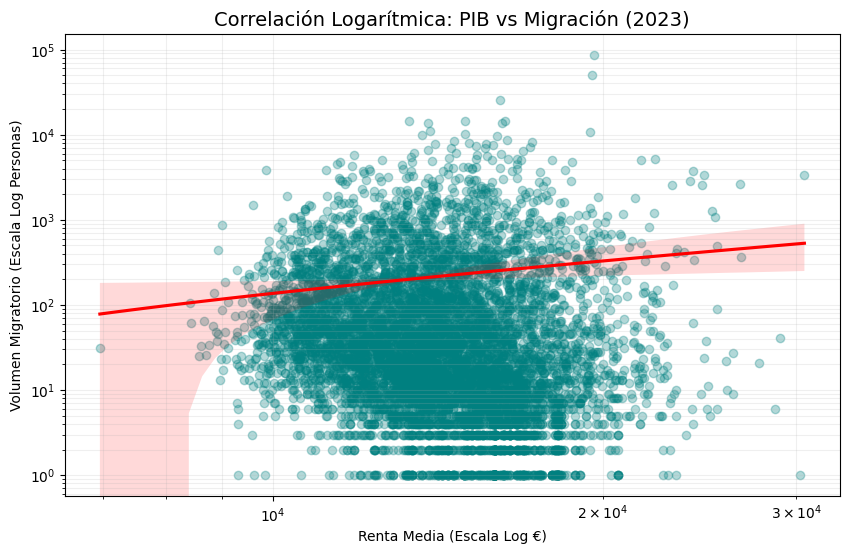

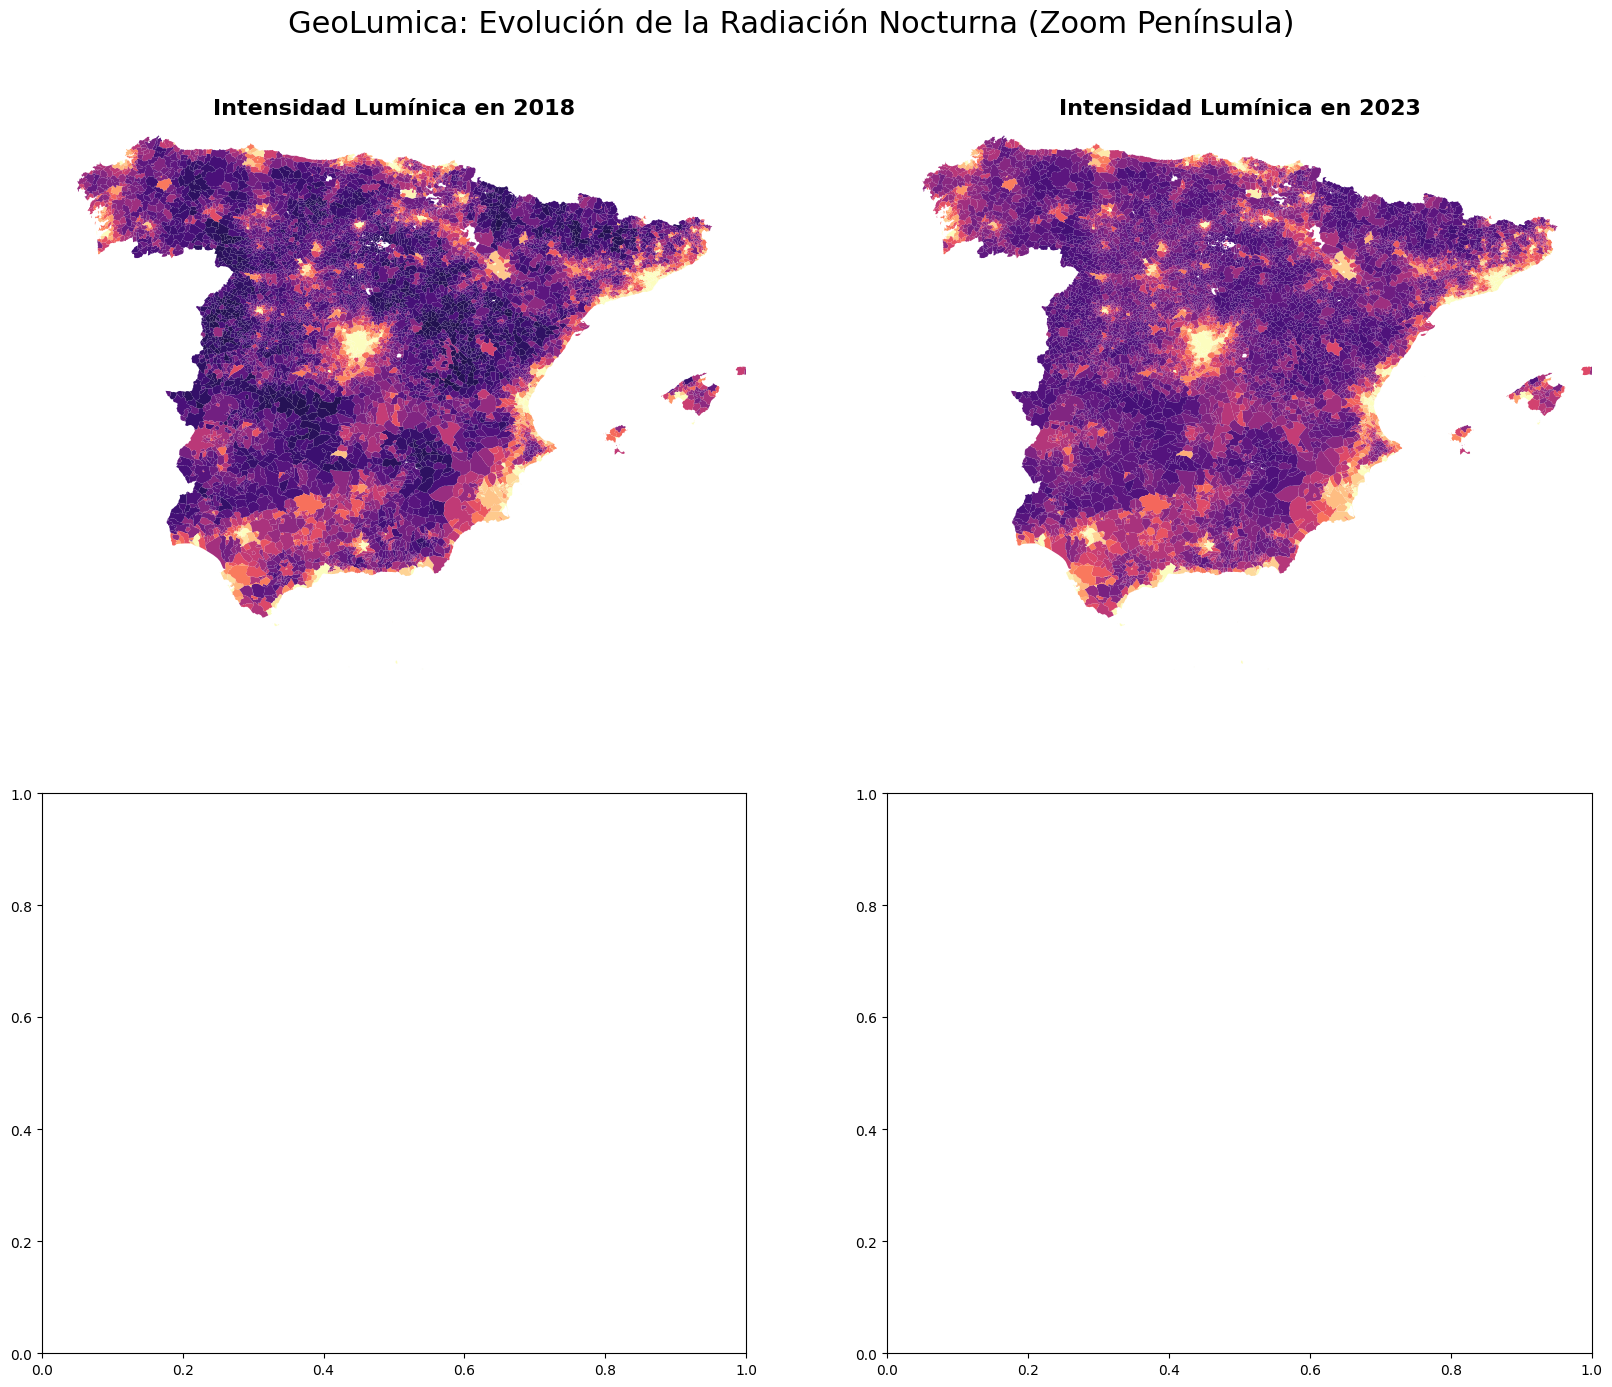

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# --- 1. SCATTER PLOT LOGARÍTMICO: PIB VS MIGRACIÓN (2023) ---
df_mig_total = df_migracion[df_migracion['nacionalidad'] == 'Total']
df_correlacion = pd.merge(df_rentamedia, df_mig_total, on=['codigo_municipio', 'anio'])
df_2023 = df_correlacion[df_correlacion['anio'] == 2023].copy()

# Eliminamos valores <= 0 para el logaritmo
df_2023 = df_2023[(df_2023['pib'] > 0) & (df_2023['cantidad (personas)'] > 0)]

plt.figure(figsize=(10, 6))
sns.regplot(data=df_2023, x='pib', y='cantidad (personas)', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})

plt.xscale('log')
plt.yscale('log')
plt.title('Correlación Logarítmica: PIB vs Migración (2023)', fontsize=14)
plt.xlabel('Renta Media (Escala Log €)')
plt.ylabel('Volumen Migratorio (Escala Log Personas)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# --- 2. SUBPLOTS VIIRS CON ZOOM PENINSULAR ---
geo_muni = gpd.read_file(r"../municipios_es.geojson")
df_viirs['codigo_id'] = df_viirs['LAU_ID'].astype(str).str.zfill(5)
df_viirs['anio_v'] = pd.to_datetime(df_viirs['date']).dt.year

años_v = [2018, 2023]
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
ax_list = axes.flatten()

# Ajustamos el contraste (percentiles) para ver mejor las zonas oscuras de 2018
vmax_v = df_viirs['mean'].quantile(0.97)

for i, anio in enumerate(años_v):
    df_temp = df_viirs[df_viirs['anio_v'] == anio].groupby('codigo_id')['mean'].mean().reset_index()
    merged_v = geo_muni.merge(df_temp, left_on='LAU_ID', right_on='codigo_id', how='left')
    
    # Graficar con límites de la Península (eliminamos Canarias/espacio vacío para zoom)
    merged_v.plot(column='mean', ax=ax_list[i], cmap='magma', 
                  norm=LogNorm(vmin=0.1, vmax=vmax_v), linewidth=0)
    
    ax_list[i].set_xlim([-10, 4])  # Zoom a la longitud de la península
    ax_list[i].set_ylim([35, 44])  # Zoom a la latitud de la península
    ax_list[i].set_title(f'Intensidad Lumínica en {anio}', fontsize=16, fontweight='bold')
    ax_list[i].set_axis_off()

plt.suptitle("GeoLumica: Evolución de la Radiación Nocturna (Zoom Península)", fontsize=22, y=0.95)
plt.show()

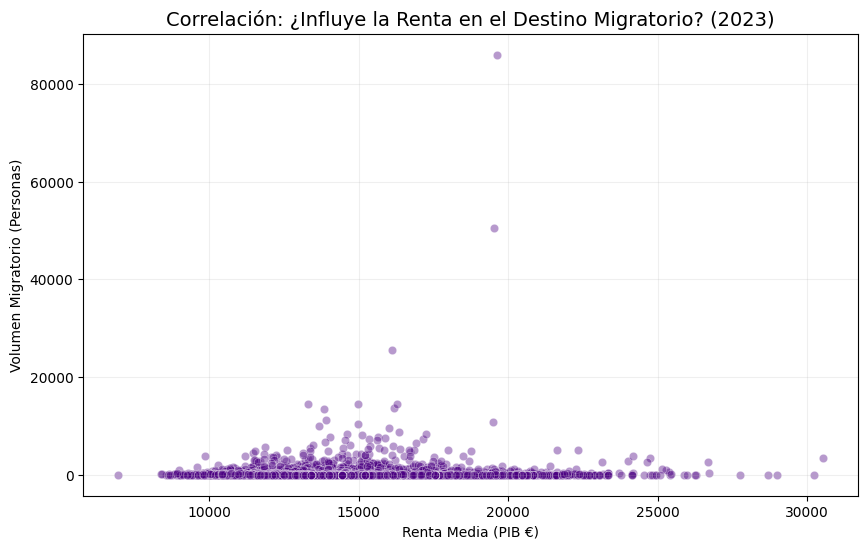

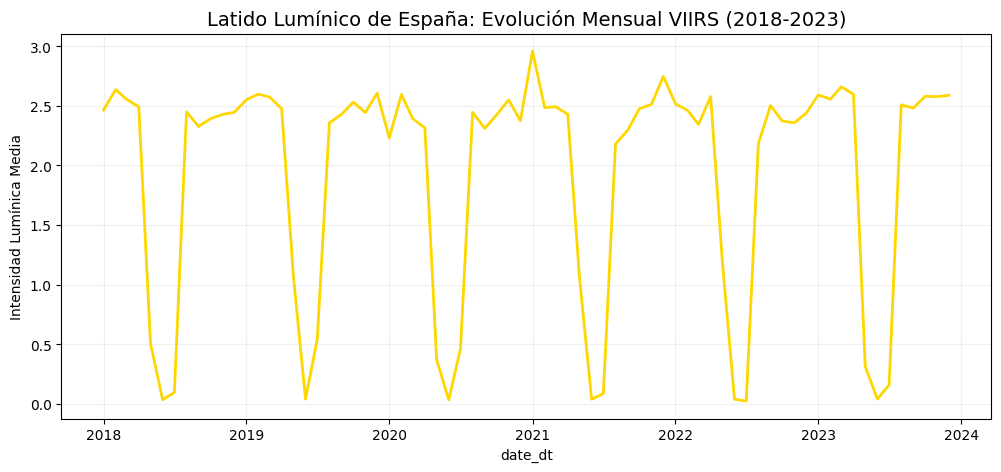

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_22848\1856897843.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




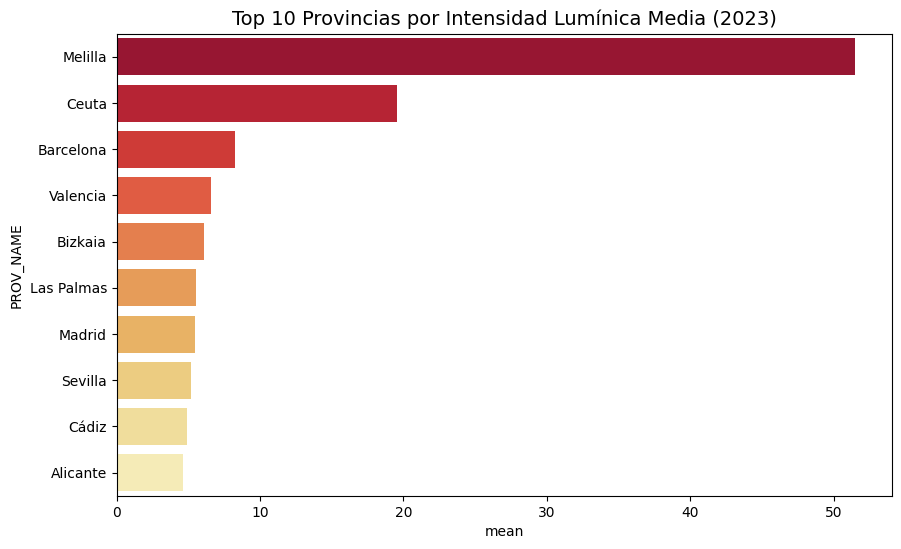

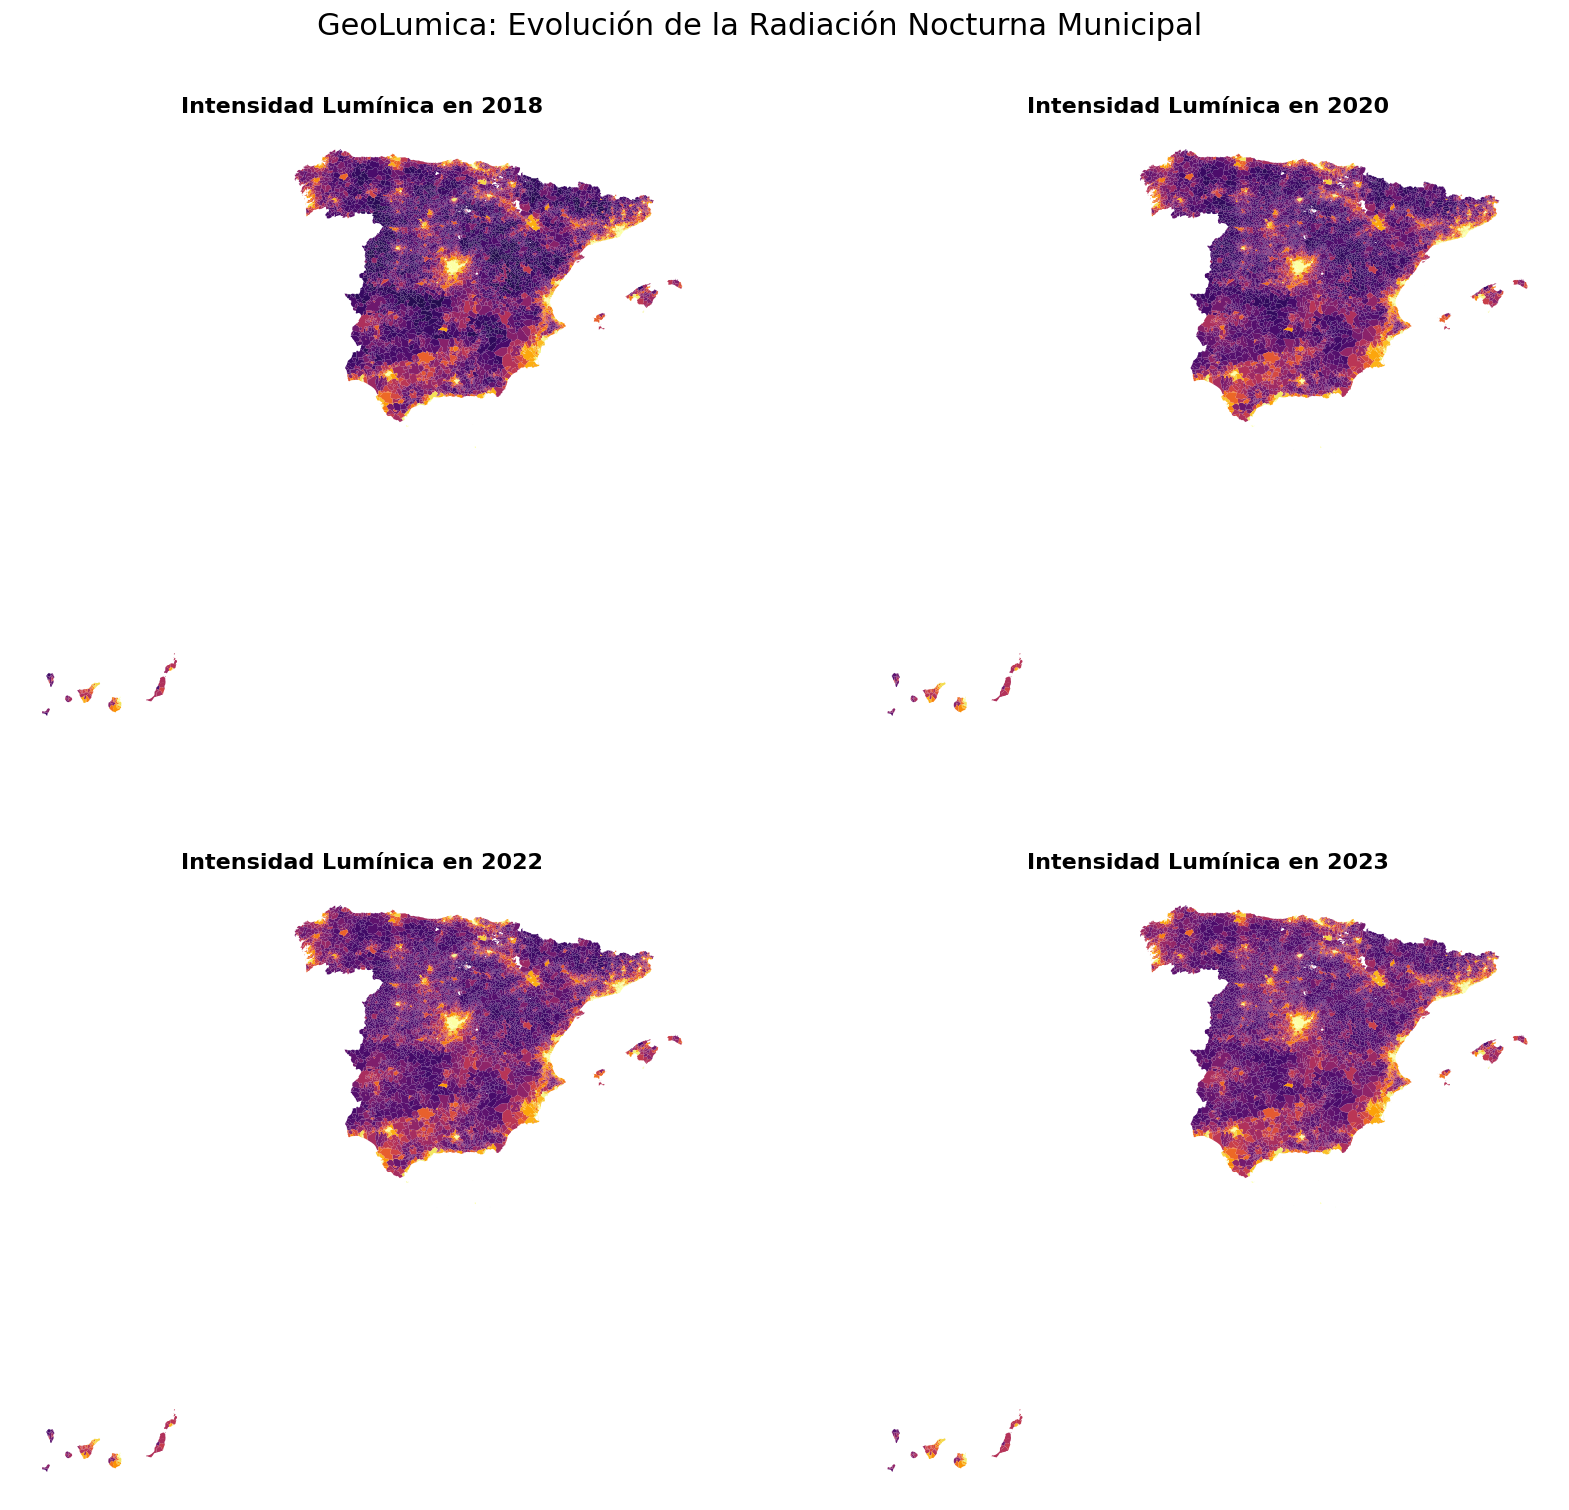

In [45]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# --- 1. SCATTER PLOT: RENTA VS MIGRACIÓN (2023) ---
# Unimos los datasets por municipio y año
df_mig_total = df_migracion[df_migracion['nacionalidad'] == 'Total']
df_correlacion = pd.merge(df_rentamedia, df_mig_total, on=['codigo_municipio', 'anio'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_correlacion[df_correlacion['anio'] == 2023], 
                x='pib', y='cantidad (personas)', alpha=0.4, color='indigo')
plt.title('Correlación: ¿Influye la Renta en el Destino Migratorio? (2023)', fontsize=14)
plt.xlabel('Renta Media (PIB €)')
plt.ylabel('Volumen Migratorio (Personas)')
plt.grid(True, alpha=0.2)
plt.show()

# --- 2. ANÁLISIS VIIRS (SATÉLITE) ---
# Preparación de la fecha y año
df_viirs['date_dt'] = pd.to_datetime(df_viirs['date'])
df_viirs['anio_v'] = df_viirs['date_dt'].dt.year

# A. Evolución Temporal del Brillo Nacional
plt.figure(figsize=(12, 5))
viirs_mensual = df_viirs.groupby('date_dt')['mean'].mean().reset_index()
sns.lineplot(data=viirs_mensual, x='date_dt', y='mean', color='gold', linewidth=2)
plt.title('Latido Lumínico de España: Evolución Mensual VIIRS (2018-2023)', fontsize=14)
plt.ylabel('Intensidad Lumínica Media')
plt.grid(True, alpha=0.2)
plt.show()

# B. Top 10 Provincias con más "Luz" (2023)
plt.figure(figsize=(10, 6))
top_luz = df_viirs[df_viirs['anio_v'] == 2023].groupby('PROV_NAME')['mean'].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=top_luz, x='mean', y='PROV_NAME', palette='YlOrRd_r')
plt.title('Top 10 Provincias por Intensidad Lumínica Media (2023)', fontsize=14)
plt.show()

# C. Subplots de Mapas: El Brillo de la Economía
geo_muni = gpd.read_file(r"../municipios_es.geojson")
df_viirs['codigo_id'] = df_viirs['LAU_ID'].astype(str).str.zfill(5)

años_v = [2018, 2020, 2022, 2023]
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
ax_list = axes.flatten()

# Usamos el percentil 98 para evitar que Madrid/Barcelona saturen todo el color
vmax_v = df_viirs['mean'].quantile(0.98)

for i, anio in enumerate(años_v):
    df_temp = df_viirs[df_viirs['anio_v'] == anio].groupby('codigo_id')['mean'].mean().reset_index()
    merged_v = geo_muni.merge(df_temp, left_on='LAU_ID', right_on='codigo_id', how='left')
    
    merged_v.plot(column='mean', ax=ax_list[i], cmap='inferno', 
                  norm=LogNorm(vmin=0.1, vmax=vmax_v), linewidth=0.01)
    ax_list[i].set_title(f'Intensidad Lumínica en {anio}', fontsize=16, fontweight='bold')
    ax_list[i].set_axis_off()

plt.suptitle("GeoLumica: Evolución de la Radiación Nocturna Municipal", fontsize=22, y=0.94)
plt.show()